<a href="https://colab.research.google.com/github/xavierjacomep/curso-intro-python/blob/main/12_PY_Lectura_de_Archivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <img src="https://upload.wikimedia.org/wikipedia/commons/9/99/Logo_UCSG.svg" width="300" alt="Logo">
</p>


# 📂 Módulo 12 — Lectura de Archivos en Python

**Tiempo estimado:** 30 minutos

---

## 🎯 Objetivos

- Abrir y leer archivos de texto con Python
- Usar `with open()` como buena práctica
- Leer línea por línea y como lista
- Procesar datos de texto para análisis

---

## ¿Por qué leer archivos?

En el mundo empresarial, los datos vienen en archivos: reportes TXT, archivos CSV, logs de sistemas. Python puede leerlos y procesarlos automáticamente, reemplazando horas de trabajo manual.

---
<hr>

## Preparación: crear un archivo de ejemplo

In [ ]:
# Primero creamos un archivo de texto para practicar
contenido = """REPORTE DE VENTAS Q1 2024
Empresa: TechCorp Ecuador
Período: Enero - Marzo 2024

Mes       Ventas    Costos    Utilidad
Enero     45000     28000     17000
Febrero   52000     31000     21000
Marzo     48000     29500     18500

Total: 145000
"""

with open('reporte_q1.txt', 'w', encoding='utf-8') as archivo:
    archivo.write(contenido)

print('Archivo de ejemplo creado: reporte_q1.txt')

## Leer un archivo con `open()`

La función `open()` abre un archivo. El parámetro `mode` indica cómo:

| Modo | Significado |
|------|-------------|
| `'r'` | Lectura (por defecto) |
| `'w'` | Escritura (sobreescribe) |
| `'a'` | Agregar al final |
| `'r+'` | Lectura y escritura |

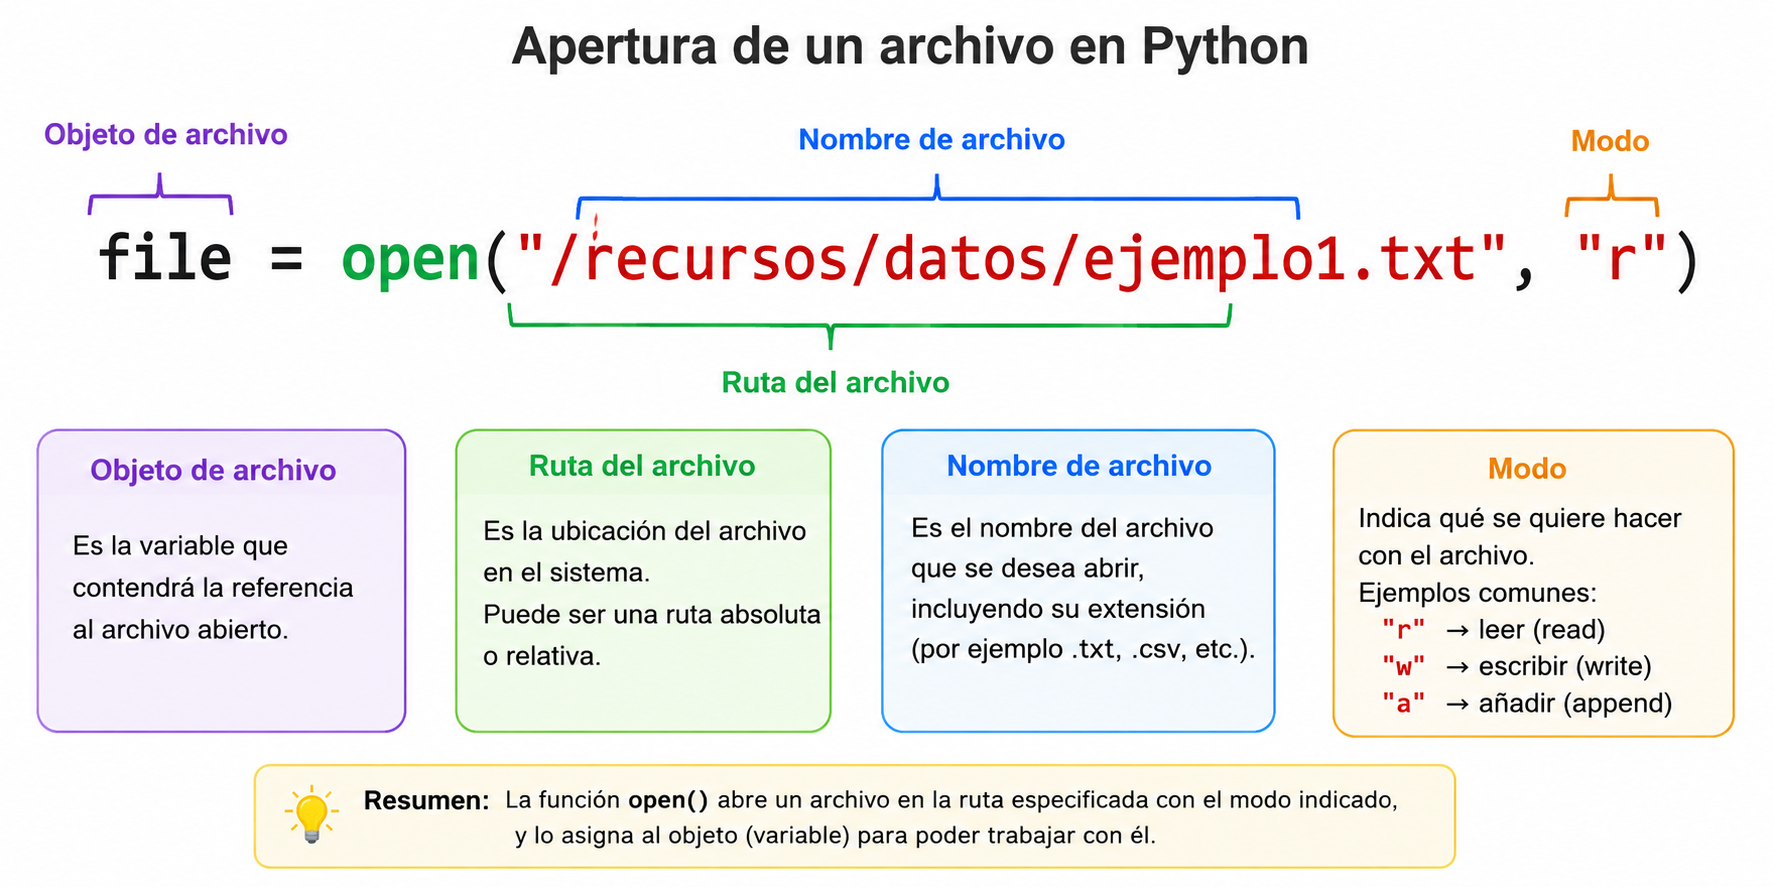

In [ ]:
# Método tradicional — recuerda cerrar el archivo con close()
archivo = open('reporte_q1.txt', 'r', encoding='utf-8')
contenido = archivo.read()
archivo.close()  # ¡Importante! Siempre cerrar

print(contenido)

## La forma correcta: `with open()`

El bloque `with` cierra el archivo automáticamente al salir, incluso si hay un error. Es la **buena práctica**.

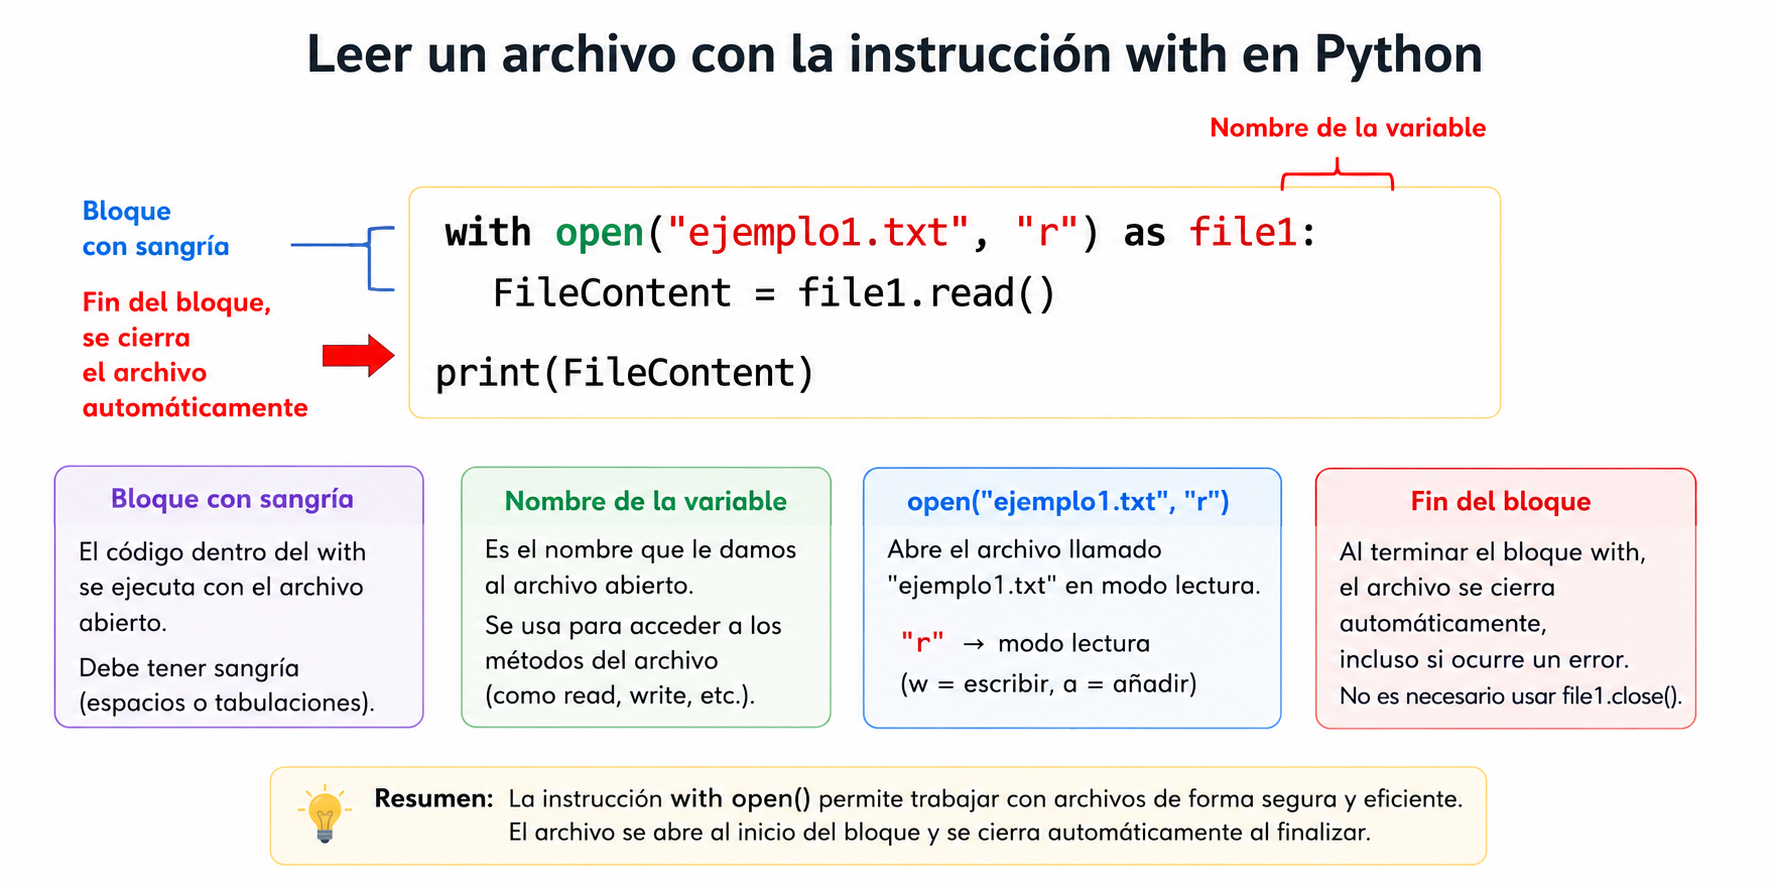

In [ ]:
# ✅ Forma recomendada con 'with'
with open('reporte_q1.txt', 'r', encoding='utf-8') as archivo:
    contenido = archivo.read()

# El archivo se cierra automáticamente al salir del bloque with
print('¿Archivo cerrado?:', archivo.closed)
print()
print(contenido)

In [ ]:
# Leer una cantidad específica de caracteres
with open('reporte_q1.txt', 'r', encoding='utf-8') as archivo:
    encabezado = archivo.read(30)
print('Primeros 30 caracteres:', encabezado)

In [ ]:
# Leer línea por línea con readline()
with open('reporte_q1.txt', 'r', encoding='utf-8') as archivo:
    primera_linea  = archivo.readline()
    segunda_linea  = archivo.readline()
    tercera_linea  = archivo.readline()

print('Línea 1:', primera_linea.strip())
print('Línea 2:', segunda_linea.strip())
print('Línea 3:', tercera_linea.strip())

In [ ]:
# Iterar sobre todas las líneas con un bucle for
print('=== Contenido línea por línea ===')
with open('reporte_q1.txt', 'r', encoding='utf-8') as archivo:
    for numero, linea in enumerate(archivo, start=1):
        print(f'{numero:2}: {linea}', end='')

In [ ]:
# Leer todas las líneas como una lista con readlines()
with open('reporte_q1.txt', 'r', encoding='utf-8') as archivo:
    lineas = archivo.readlines()

print('Total de líneas:', len(lineas))
print('Primera línea:', lineas[0].strip())
print('Última línea: ', lineas[-1].strip())

## Procesamiento de datos desde archivos de texto

In [ ]:
# Crear un archivo CSV simple para procesar
datos_csv = """producto,precio,cantidad,categoria
Laptop,899,5,Electronica
Mouse,25,50,Accesorios
Teclado,75,30,Accesorios
Monitor,350,8,Electronica
Silla,280,12,Muebles
Escritorio,450,4,Muebles
"""

with open('inventario.txt', 'w', encoding='utf-8') as f:
    f.write(datos_csv)

print('Archivo inventario.txt creado')

In [ ]:
# Procesar el archivo CSV manualmente
inventario = []

with open('inventario.txt', 'r', encoding='utf-8') as archivo:
    encabezado = archivo.readline().strip().split(',')

    for linea in archivo:
        if linea.strip():  # ignorar líneas vacías
            campos = linea.strip().split(',')
            registro = {
                'producto' : campos[0],
                'precio'   : float(campos[1]),
                'cantidad' : int(campos[2]),
                'categoria': campos[3]
            }
            inventario.append(registro)

# Mostrar los datos procesados
print(f"{'Producto':12} {'Precio':>8} {'Cantidad':>9} {'Valor Total':>12} {'Categoría'}")
print('-' * 60)

total_inventario = 0
for item in inventario:
    valor = item['precio'] * item['cantidad']
    total_inventario += valor
    print(f"{item['producto']:12} ${item['precio']:>7,.0f} {item['cantidad']:>9} ${valor:>11,.0f} {item['categoria']}")

print('-' * 60)
print(f"{'TOTAL':43} ${total_inventario:>11,.0f}")

## 🧪 Ejercicio

**Ejercicio:** Lee el archivo `reporte_q1.txt` y extrae solo las líneas que contienen datos de ventas (Enero, Febrero, Marzo). Calcula el total de la columna Ventas.

In [ ]:
# Escribe tu código aquí
meses = ['Enero', 'Febrero', 'Marzo']


<details><summary>📌 Solución</summary>

```python
meses = ['Enero', 'Febrero', 'Marzo']
total_ventas = 0

with open('reporte_q1.txt', 'r', encoding='utf-8') as archivo:
    for linea in archivo:
        partes = linea.split()
        if partes and partes[0] in meses:
            ventas = int(partes[1])
            total_ventas += ventas
            print(f'{partes[0]:10}: ${ventas:,}')

print(f'\nTotal ventas: ${total_ventas:,}')
```
</details>

<hr>

## ✅ Resumen del Módulo 12

- **`open(archivo, modo, encoding)`**: abre un archivo
- **`with open(...) as f:`**: forma correcta, cierra automáticamente
- **`f.read()`**: lee todo el contenido como string
- **`f.readline()`**: lee una sola línea
- **`f.readlines()`**: lee todas las líneas como lista
- **`for linea in archivo:`**: itera sobre las líneas
- Siempre usa `encoding='utf-8'` para evitar problemas con tildes y caracteres especiales

Siguiente: **Escritura de archivos** — guardar datos procesados. 🚀